PyTorch implementation of **ResNet-18** as discussed in _'Deep Residual Learning for Image Recognition'_ (He et al., 2015)

In [1]:
import os
import time     # for recording training duration
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# FOR REPRODUCIBILITY
seed = 92

os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # forces cuDNN to use deterministic algorithms only
    torch.backends.cudnn.deterministic = True
    # disables cuDNN autotuner that selects optimal algorithm based on hardware
    torch.backends.cudnn.benchmark = False

# force shuffling of samples in dataloader to be deterministic
generator = torch.Generator().manual_seed(seed)

In [5]:
# hyperparameters
learningrate = 0.01
batchsize = 128
epochs = 75

momentum = 0.9
weightdecay = 5e-4

In [6]:
datapath = "../data"

# loading Imagenette
train_imagenette = datasets.Imagenette(
    root=datapath,
    split="train",
    download=True,
    transform=transforms.Compose([
        transforms.Resize(256),
        # trying random crop here to test if it helps
        transforms.RandomCrop(224),
        transforms.ToTensor()
    ])
)
test_imagenette = datasets.Imagenette(
    root=datapath,
    split="val",
    download=True,
    transform=transforms.Compose([
        transforms.Resize(256),
        # cropping to centre for deterministic evaluation
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ])
)

trainloader_imagenette = DataLoader(
    train_imagenette,
    batch_size=batchsize,
    shuffle=True,
    generator=generator
)
testloader_imagenette = DataLoader(
    test_imagenette,
    batch_size=batchsize,
    shuffle=False
)

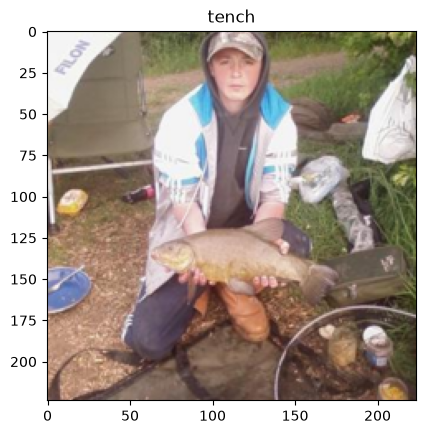

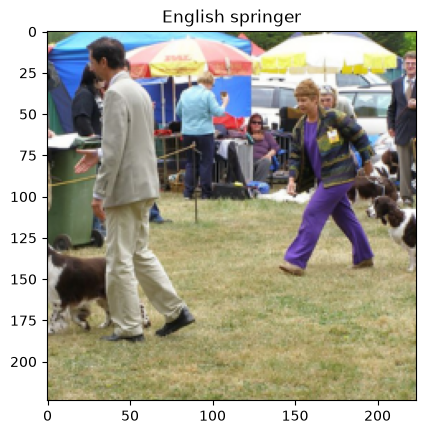

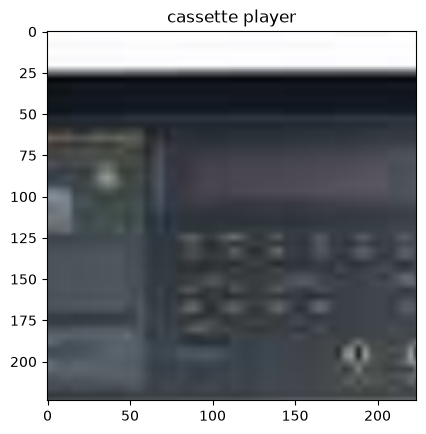

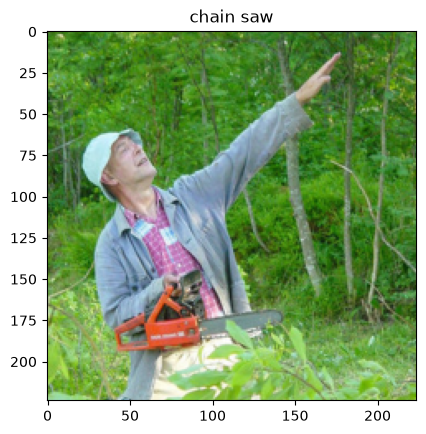

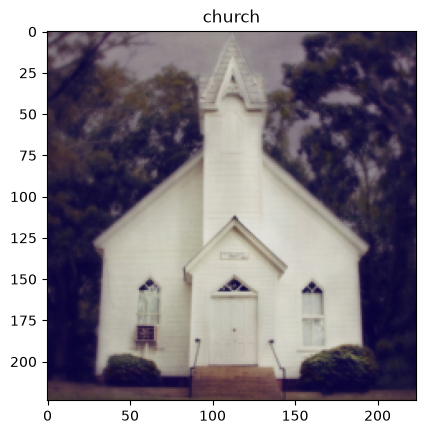

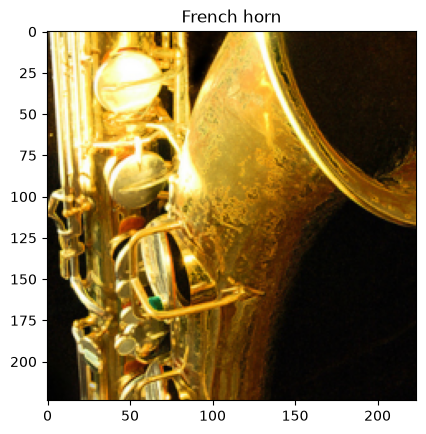

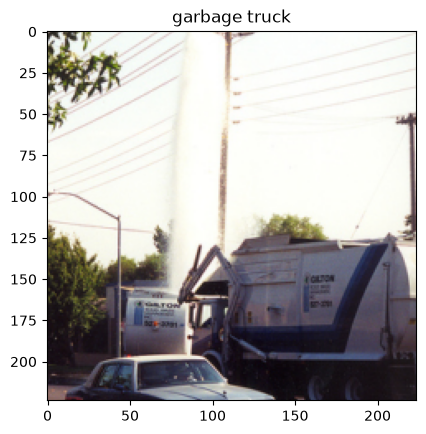

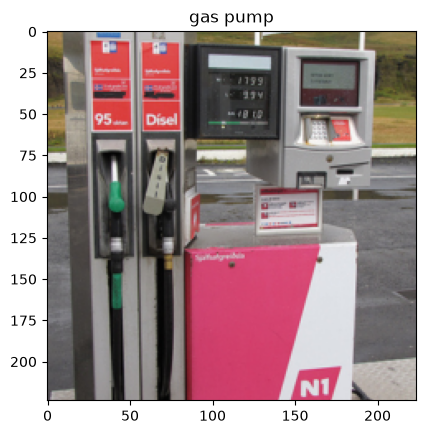

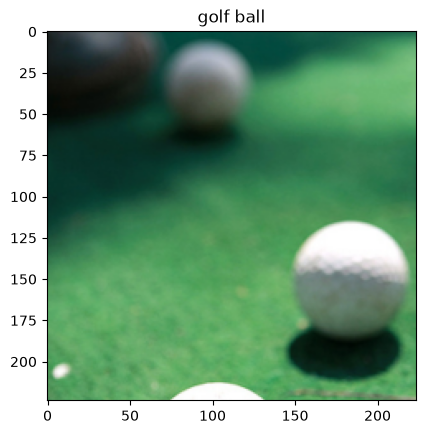

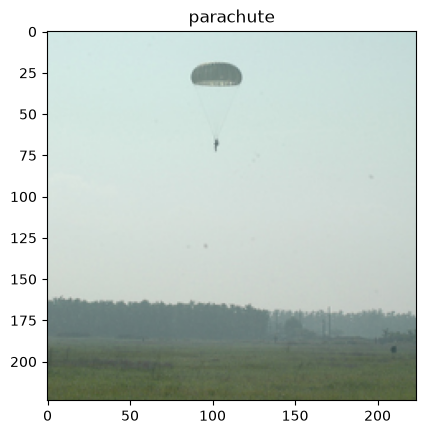

In [7]:
classes = train_imagenette.classes

images, labels = next(iter(trainloader_imagenette))
for i in range(10):
    index = np.argmax(labels.numpy() == i)
    plt.imshow(images[index].permute(1, 2, 0))
    plt.title(classes[i][0])
    plt.show()